# Notebook 01 - Pre-match microstructure

This notebook describes the basic microstructure of the pre-match Betfair exchange: how liquidity and price activity evolve as kick-off approaches. It works from the fixed input market_data.csv and produces three figures and one supporting table.

- Figure 5.1, volatility (variance of log-prob returns) against time-to-kick-off: price variability rises as the match nears.
- Figure 5.2, median back-lay spread against time-to-kick-off: the quoted spread, a liquidity-cost proxy, compresses toward kick-off.
- Figure 5.3, quote-update intensity against time-to-kick-off: the rate of quote updates increases sharply near kick-off, fastest in Match Odds.
- Liquidity-by-favourite table: favourites trade at tighter spreads than outsiders.

Time-to-kick-off (tau) is the key variable throughout, defined as scheduled kick-off minus timestamp in minutes, so tau counts down to zero at kick-off. The pipeline is: load and restrict to the pre-match window, clean the order book, build features (implied probability, spread, tick returns), and summarise each quantity by tau.

To reproduce, place the dataset at ../data/raw/market_data.csv and run all cells in order. Figures (PNG and PDF), tables (CSV and LaTeX), the cleaned dataset, and a run-metadata file are written to ../outputs/01_microstructure_analysis/.

## Code attribution

Library-provided functionality in this notebook: data loading, timestamp parsing, forward-filling, grouping and resampling (pandas); figures (Matplotlib, Seaborn). These are used as standard tooling and are not attributed line by line.

## 1. Configuration and reproducibility

Fixes the random seed, resolves the input path (and stops early if market_data.csv is missing), creates the output folders, and writes a run-metadata file recording the timestamp, seed, Python version, and input file.

In [9]:
"""
Configuration and Reproducibility Setup
========================================
This cell configures paths, random seeds, and output directories.
The data path can be set via environment variable or uses a default relative path.
"""

import os
import sys
import json
from pathlib import Path
from datetime import datetime, timezone
import random
import numpy as np

# Configuration

SEED = 42
NOTEBOOK_NAME = "01_microstructure_analysis"

# Random seeds for reproducibility

random.seed(SEED)
np.random.seed(SEED)

# Data Path
DATA_PATH = Path("../data/raw/market_data.csv")

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Data file not found at: {DATA_PATH.resolve()}\n"
        "Place market_data.csv in ../data/raw/ (see README)."
    )

# Output Directories

OUTPUT_DIR = Path(f"../outputs/{NOTEBOOK_NAME}")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATA_OUT_DIR = OUTPUT_DIR / "data" 

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUT_DIR.mkdir(parents=True, exist_ok=True)


# Run Metadata

metadata = {
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "notebook": NOTEBOOK_NAME,
    "seed": SEED,
    "python_version": sys.version.split()[0],
    "data_file": DATA_PATH.name
}

with open(OUTPUT_DIR / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Random seed: {SEED}")

Data path: ..\data\raw\market_data.csv
Output directory: ..\outputs\01_microstructure_analysis
Random seed: 42


## 2. Libraries and output helpers

The analysis stack (pandas, matplotlib, seaborn) plus two helper functions. save_figure writes each figure as both PNG and PDF; save_table writes each table as both CSV and LaTeX for direct insertion into the write-up. Routing all outputs through these helpers means each figure and table is regenerated to a known file path.

In [10]:
"""
Library Imports and Plot Settings
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [11]:
"""
Output Helper Functions
"""

def save_figure(name, fig=None):
    """Save figure as both PNG and PDF."""
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig = fig or plt.gcf()

    png_path = FIG_DIR / f"{name}.png"
    pdf_path = FIG_DIR / f"{name}.pdf"

    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved: {png_path.name}, {pdf_path.name}")
    return png_path, pdf_path


def save_table(df, name, index=False):
    """Save DataFrame as both CSV and LaTeX."""
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

    csv_path = TABLE_DIR / f"{name}.csv"
    tex_path = TABLE_DIR / f"{name}.tex"

    df.to_csv(csv_path, index=index)
    df.to_latex(tex_path, index=index, float_format="%.4f")

    print(f"Saved: {csv_path.name}, {tex_path.name}")
    return csv_path, tex_path


## 3. Loading, filtering, and cleaning the tick data

load_and_filter_time reads the CSV, checks the expected columns are present, and restricts the data to the pre-match window. Timestamps are parsed as UTC and then made timezone-naive so both ts_utc and market_time sit on one consistent clock; the exported CSV carries a +01:00 offset from a London session, and parsing with utc=True normalises this so tau is computed correctly. Pre-match is defined directly as ts_utc < market_time, which is more robust than relying on an in-play flag. Tau is restricted to the final 360 minutes before kick-off, the window where the market is liquid and the deadline dynamics are visible.

clean_microstructure handles two order-book features. A best quote shown with a size of zero is not tradable, so its price is set to missing before any forward-fill. The exchange only republishes a price when it changes, so prices are forward-filled within each event, market, and selection to reconstruct the prevailing best quote at every timestamp. Rows with no reconstructable two-sided quote are then dropped, which is a small fraction once the fill is applied.

In [ ]:
def load_and_filter_time(path, min_tau=0, max_tau=360):
    """Loads raw data and filters for the pre-match window."""
    print(">>> Loading Data...")

    df = pd.read_csv(path)
    
    # Required columns (fail fast if schema changes)
    required_cols = [
        "event_id", "market_id", "selection_id",
        "ts_utc", "market_time",
        "best_back_price", "best_back_size",
        "best_lay_price", "best_lay_size"
    ]

    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    
    # Parse timestamps to UTC naive
    for col in ['ts_utc', 'market_time']:
        df[col] = pd.to_datetime(df[col], utc=True).dt.tz_localize(None)
        
    # Filter Pre-match
    df = df[df["ts_utc"] < df["market_time"]].copy()
    
    # Calculate Tau (Time to Kickoff)
    df["tau_minutes"] = (df["market_time"] - df["ts_utc"]) / pd.Timedelta(minutes=1)
    
    # Filter Window
    df = df[df["tau_minutes"].between(min_tau, max_tau)].copy()
    
    # Sort
    df = df.sort_values(["event_id", "market_id", "selection_id", "ts_utc"])
    
    print(f"Data Loaded: {len(df):,} rows within {min_tau}-{max_tau} min window.")
    return df

# Order-book cleaning
def clean_microstructure(df):
    """Removes ghost liquidity and forward-fills prices."""
    print(">>> Cleaning Microstructure...")
    
    df = df.copy()

    # Handle ghost liquidity - Size=0 means Price is invalid
    for side in ["back", "lay"]:
        mask_zero = df[f"best_{side}_size"] == 0
        df.loc[mask_zero, f"best_{side}_price"] = np.nan
        
    # Forward Fill - Prices persist until changed
    cols = ["best_back_price", "best_back_size", "best_lay_price", "best_lay_size"]
    # Groupby forward fill
    df[cols] = df.groupby(["event_id", "market_id", "selection_id"])[cols].ffill()
    
    # Drop incomplete rows
    df = df.dropna(subset=["best_back_price", "best_lay_price"])
    
    print(f"Cleaning Complete: {len(df):,} rows valid.")
    return df

## 4. Feature construction

add_features turns cleaned quotes into the quantities the analysis needs. The mid-quote is the average of best back and best lay, and the spread is best lay minus best back, used as a proxy for the round-trip liquidity cost. This spread is in odds units (the difference of two decimal odds). The mid odds are inverted to an implied probability and then logged.

Returns are the tick-to-tick change in log-probability within each series. The inter-tick gap is also computed, and returns spanning a gap longer than 30 minutes are dropped, since a return measured across a long dead period is a stale jump rather than a genuine high-frequency move and would inflate the volatility estimate. The qualitative results are not sensitive to using 15 or 60 minutes instead.

In [ ]:
# Feature construction - mid, spread, implied probability, log-probability, tick returns, 
# and the staleness filter that drops returns spanning gaps longer than 30 minutes.
def add_features(df):
    """Calculates log-prob, spreads, and realized volatility."""
    
    # 1. Midquote & Spread
    df["mid"] = (df["best_back_price"] + df["best_lay_price"]) / 2.0
    df["spread"] = df["best_lay_price"] - df["best_back_price"]
    
    # 2. Log-Probability - the 'Price' 
    # Filter unrealistic odds first
    df = df[df["mid"] <= 100].copy()
    df["implied_prob"] = 1.0 / df["mid"]
    df["log_prob"] = np.log(df["implied_prob"])
    
    # 3. Returns Volatility and Staleness Filter
    g = ["event_id", "market_id", "selection_id"]
    df["log_prob_return"] = df.groupby(g)["log_prob"].diff()
    df["dt_minutes"] = df.groupby(g)["ts_utc"].diff().dt.total_seconds() / 60.0
    
    # Remove first tick (NaN) and stale ticks (>30 mins)
    df = df.dropna(subset=["log_prob_return", "dt_minutes"])
    df = df[df["dt_minutes"] <= 30].copy()
    
    print(f"Features Added: {len(df):,} rows ready for analysis.")
    return df

## 5. Microstructure results (Figures 5.1-5.3 and the liquidity table)

Each function below bins the data by time-to-kick-off and summarises one microstructure quantity. All three figures invert the x-axis so kick-off (tau = 0) sits on the right.

Figure 5.1, volatility, is the variance of tick-to-tick log-probability returns in each 5-minute tau-bin, with a 15-minute smoothed line; volatility rises toward kick-off. This is built from tick-to-tick returns, so it reflects bid-ask bounce and the changing update frequency near kick-off; it is a descriptive measure of price variability rather than an interval-standardised integrated variance.

Figure 5.2, median back-lay spread, is the median spread in odds units per 5-minute tau-bin, smoothed; the spread compresses toward kick-off. The median is used rather than the mean because the spread distribution has a heavy right tail. Obvious data errors (crossed or zero spreads, and spreads above 3) are removed first.

Figure 5.3, quote-update intensity, is the number of published quote updates per 5-minute bar, by market, for the three core markets, summarised as the median per 15-minute tau-bin; activity rises sharply near kick-off, fastest in Match Odds. This counts published rows per market, so the trend is the claim and the absolute levels are not directly comparable across markets with different numbers of selections.

The liquidity-by-favourite table splits spreads by whether a Match Odds selection is the favourite (shortest mean odds) or an outsider; favourites show tighter spreads. The absolute odds-spread scales with the odds level, so part of this gap is mechanical (outsiders sit at higher odds where the absolute spread is naturally larger); a relative spread would separate the two effects.

In [ ]:
def plot_volatility(df):
    """Figure 5.1: variance of tick log-prob returns vs time-to-kick-off."""
    print("Generating Figure 5.1 (Volatility)...")
    
    # Binning
    df["tau_bin"] = (df["tau_minutes"] // 5.0) * 5.0
    
    summary = (df.groupby("tau_bin")["log_prob_return"]
               .agg(var="var")
               .reset_index().sort_values("tau_bin"))
    
    # Smooth (Window 3, Mean)
    summary["var_smooth"] = summary["var"].rolling(3, center=True).mean().bfill().ffill()
    
    # Plot
    plt.figure(figsize=(9, 5))
    plt.plot(summary["tau_bin"], summary["var"], alpha=0.3, label="Raw Variance")
    plt.plot(summary["tau_bin"], summary["var_smooth"], color='red', lw=2, label="Smoothed (15m)")
    plt.gca().invert_xaxis()
    plt.xlabel("Minutes to Kickoff")
    plt.ylabel("Variance (Log-Probability Returns)")
    plt.legend()
    plt.tight_layout()

    save_figure("fig_5_1_volatility")
    plt.show()

    return summary

def plot_spreads(df):
    """Figure 5.2: median back-lay spread (odds units) vs time-to-kick-off."""
    print("Generating Figure 5.2 (Spreads)...")
    
    # Drop obvious data errors only: crossed/zero spreads and wide (>3 odds) spreads.
    clean = df[(df["spread"] > 0) & (df["spread"] < 3)].copy()
    
    # Binning
    clean["tau_bin"] = (clean["tau_minutes"] // 5.0) * 5.0
    
    # Aggregation
    spread_summary = (clean.groupby("tau_bin")["spread"]
                      .agg(median_spread='median')
                      .reset_index()
                      .sort_values("tau_bin"))
    
    # Smoothing (Median Rolling)
    spread_summary["smoothed"] = (spread_summary["median_spread"]
                                  .rolling(window=3, center=True, min_periods=1)
                                  .median())
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(spread_summary["tau_bin"], spread_summary["smoothed"], 
             color='blue', lw=2, label="Smoothed Median Spread (15 min)")
    plt.gca().invert_xaxis()
    plt.xlabel("Time to Kickoff (minutes)")
    plt.ylabel("Median Back-Lay Spread (odds units)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_figure("fig_5_2_spread")
    plt.show()

    return spread_summary

def plot_quote_intensity(df):
    """Figure 5.3: quote-update intensity (published updates per 5 min) vs time-to-kick-off."""
    print("Generating Figure 5.3 (Quote Intensity)...")
    
    # Filter Core Markets
    core_markets = ["Match Odds", "Over/Under 2.5 Goals", "Both teams to Score?"]
    df_int = df[df["market_name"].isin(core_markets)].copy()
    
    # Define 5-minute bars
    df_int["bar_time"] = df_int["ts_utc"].dt.floor("5min")
    
    # Count Ticks per (Market, Bar)
    intensity_raw = (df_int.groupby(["market_name", "bar_time"])
                     .size()
                     .reset_index(name="intensity"))
    
    # Add Mean Tau per Bar (for plotting x-axis)
    tau_lookup = df_int.groupby(["market_name", "bar_time"])["tau_minutes"].mean().reset_index()
    intensity = intensity_raw.merge(tau_lookup, on=["market_name", "bar_time"])
    
    # Bin into 15-minute intervals
    intensity["tau_bin"] = (intensity["tau_minutes"] // 15.0) * 15.0
    
    # Aggregate Median Intensity per Bin
    intensity_summary = (intensity.groupby(["market_name", "tau_bin"])["intensity"]
                         .median()
                         .reset_index())
    
    # Plot
    plt.figure(figsize=(10, 6))
    for mkt in core_markets:
        sub = intensity_summary[intensity_summary["market_name"] == mkt]
        if not sub.empty:
            plt.plot(sub["tau_bin"], sub["intensity"], marker="o", label=mkt)
            
    plt.gca().invert_xaxis()
    plt.xlabel("Time to Kickoff (minutes)")
    plt.ylabel("Median Quote Updates (per 5 min)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_figure("fig_5_3_intensity")
    plt.show()

    return intensity_summary

def analyze_favourites(df):
    """Table: Spread Analysis by Favourite Status"""
    print("Generating Favourite Analysis Table...")
    
    df = df[df["market_name"] == "Match Odds"].copy()

    # Flag Favourites
    # We group transform to find min odds in each market
    avg_mid = df.groupby(["event_id", "market_id", "selection_id"])["mid"].mean().reset_index()
    avg_mid["fav_flag"] = avg_mid.groupby(["event_id", "market_id"])["mid"].transform(lambda x: x == x.min())
    
    # Merge flag back to main data
    df_clean = df[(df["spread"] > 0) & (df["spread"] < 3)].copy()
    
    df_fav = df_clean.merge(
        avg_mid[["event_id", "market_id", "selection_id", "fav_flag"]],
        on=["event_id", "market_id", "selection_id"],
        how="left"
    )
    
    # Aggregate
    fav_summary = (
        df_fav.groupby("fav_flag")["spread"]
        .agg(
            n_ticks="count",
            median_spread="median",
            mean_spread="mean"
        )
        .reset_index()
    )
    
    # Format for display
    fav_summary["fav_flag"] = fav_summary["fav_flag"].map({True: "Favourite", False: "Outsider"})
    
    print("\n=== TABLE: LIQUIDITY BY FAVOURITE STATUS ===")
    print(fav_summary)
    save_table(fav_summary, "table_fav_liquidity", index=False)
    return fav_summary

## 6. Execution pipeline

Runs the whole analysis in order (load, clean, features, the three figures and the table) and saves the cleaned analysis dataset to clean_microstructure_data.csv. Running it top to bottom regenerates every Notebook 01 output from the single input file.

>>> Loading Data...
Data Loaded: 11,384,468 rows within 0-360 min window.
>>> Cleaning Microstructure...
Cleaning Complete: 11,328,551 rows valid.
Features Added: 11,053,395 rows ready for analysis.
Generating Figure 5.1 (Volatility)...
Saved: fig_5_1_volatility.png, fig_5_1_volatility.pdf


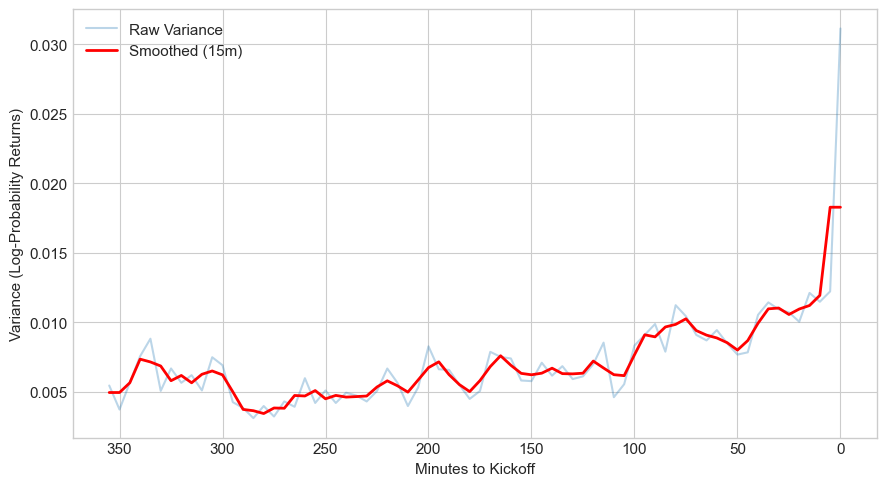

Generating Figure 5.2 (Spreads)...
Saved: fig_5_2_spread.png, fig_5_2_spread.pdf


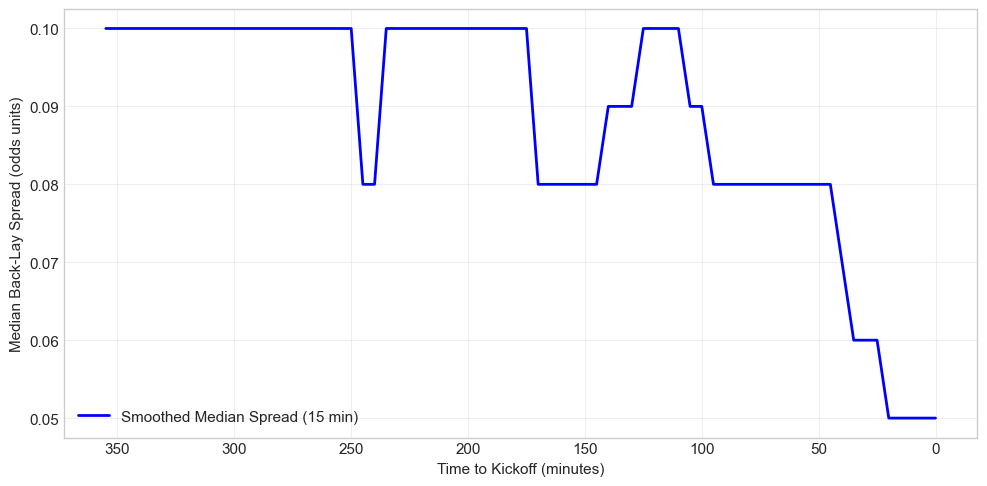

Generating Figure 5.3 (Quote Intensity)...
Saved: fig_5_3_intensity.png, fig_5_3_intensity.pdf


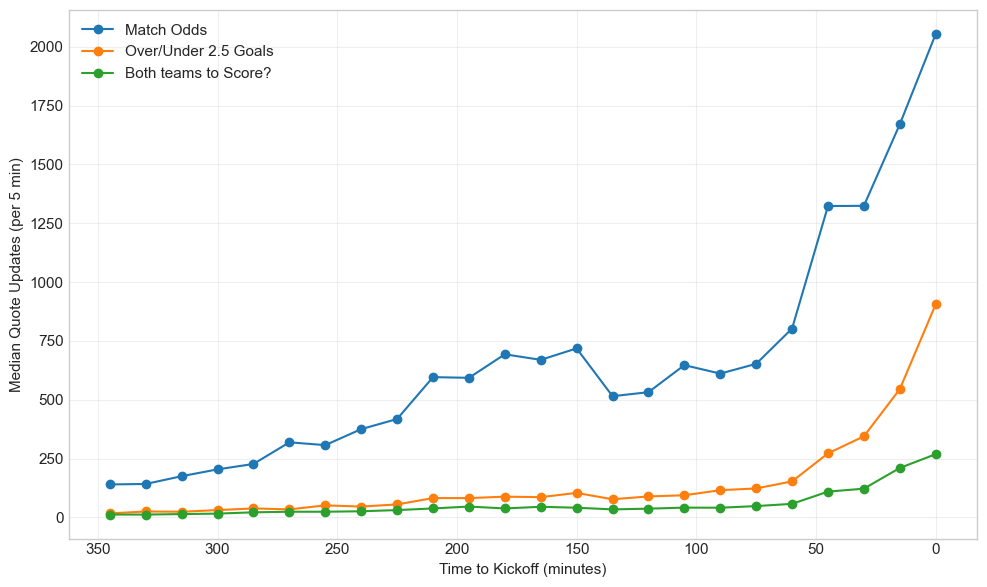

Generating Favourite Analysis Table...

=== TABLE: LIQUIDITY BY FAVOURITE STATUS ===
    fav_flag  n_ticks  median_spread  mean_spread
0   Outsider  3722930         0.2000       0.3163
1  Favourite  3235850         0.0300       0.0840
Saved: table_fav_liquidity.csv, table_fav_liquidity.tex
>>> Saving 11,053,395 rows to ..\outputs\01_microstructure_analysis\data\clean_microstructure_data.csv...
Done.


In [ ]:
# Main Pipeline

# Run Pipeline
df_raw = load_and_filter_time(DATA_PATH)
df_clean = clean_microstructure(df_raw)
df_final = add_features(df_clean)

# Run Analysis
plot_volatility(df_final)
plot_spreads(df_final)
plot_quote_intensity(df_final) 
analyze_favourites(df_final)

# Save Final Dataset
cols = ["event_id", "market_id", "selection_id", "ts_utc", "tau_minutes", "mid", "log_prob", "spread", "log_prob_return"]
save_path = DATA_OUT_DIR /"clean_microstructure_data.csv"
print(f">>> Saving {len(df_final):,} rows to {save_path}...")
df_final[cols].to_csv(save_path, index=False)
print("Done.")

## 7. Data validation and quality checks

A final check on the raw loaded data. It confirms the sample size and that the data spans the expected season, reports the missing rate by key column, and summarises the inter-update time within each event, market, and selection series. The high missing rate on individual price columns is expected and is why the cleaning step forward-fills standing quotes; the short median inter-update time confirms the feed is high-frequency.

In [ ]:
import pandas as pd

print("Rows:", len(df_raw))
print("Events (unique event_id):", df_raw["event_id"].nunique())

# Time coverage (based on scheduled kick-off)
mt = pd.to_datetime(df_raw["market_time"], errors="coerce")
print("market_time range:", mt.min(), "→", mt.max())

# Basic completeness for key columns
key_cols = ["ts_utc","market_time","event_id","market_name","selection_name","best_back_price","best_lay_price"]
missing = df_raw[key_cols].isna().mean().sort_values(ascending=False)
print("\nMissing rate (key cols):")
print((missing*100).round(2).astype(str) + "%")

# Are sizes present
size_cols = [c for c in ["best_back_size","best_lay_size"] if c in df_raw.columns]
print("\nSize columns present:", size_cols)
if size_cols:
    print("Missing rate (size cols):")
    print((df_raw[size_cols].isna().mean()*100).round(2))


# Ensure ts_utc is datetime
df_raw["ts_utc"] = pd.to_datetime(df_raw["ts_utc"], errors="coerce")

# Sort so diffs make sense
d = df_raw.sort_values(["event_id", "market_name", "selection_name", "ts_utc"]).copy()

# Inter-update gap in seconds within each runner series
d["dt_sec"] = d.groupby(["event_id", "market_name", "selection_name"])["ts_utc"].diff().dt.total_seconds()

gaps = d["dt_sec"].dropna()

print("Inter-update time (seconds) within (event, market, selection):")
print("N gaps:", len(gaps))
print("Median:", gaps.median())
print("P25:", gaps.quantile(0.25))
print("P75:", gaps.quantile(0.75))
print("P95:", gaps.quantile(0.95))

by_mkt = d.groupby("market_name")["dt_sec"].median().sort_values()
print("\nMedian inter-update time by market_name (sec):")
print(by_mkt)



Rows: 11384468
Events (unique event_id): 290
market_time range: 2015-08-08 14:00:00 → 2016-04-30 16:30:00

Missing rate (key cols):
best_lay_price     60.86%
best_back_price    54.49%
ts_utc               0.0%
event_id             0.0%
market_time          0.0%
selection_name       0.0%
market_name          0.0%
dtype: object

Size columns present: ['best_back_size', 'best_lay_size']
Missing rate (size cols):
best_back_size   54.4900
best_lay_size    60.8600
dtype: float64
Inter-update time (seconds) within (event, market, selection):
N gaps: 11381278
Median: 0.376
P25: 0.067
P75: 2.004
P95: 20.688

Median inter-update time by market_name (sec):
market_name
Match Odds             0.3220
Over/Under 2.5 Goals   0.3690
Over/Under 3.5 Goals   0.6440
Over/Under 1.5 Goals   0.7290
Both teams to Score?   1.1180
Name: dt_sec, dtype: float64
